# Speed

This benchmark focuses on comparing the **speed** of ``pyMultiFit``'s statistical distribution generations compared to the well-established ``SciPy`` library.
The focus is on ensuring that ``pyMultiFit`` provides reliably faster generation that closely match or are better than SciPy running time.

## What is Tested?

- Probability Density Function (PDF): Evaluates the time taken to compute the PDF for a set of input values.
- Cumulative Distribution Function (CDF): Measures the performance of computing cumulative probabilities.

## Benchmark setup

To test accuracy:

- Both ``pyMultiFit`` and SciPy are run on the same input data, using distributions like Gaussian, Beta, and Laplace.
- Results are compared using metrics such as absolute error, relative error, and visual plots.
- A range of parameter values and edge cases are included to evaluate robustness and consistency.

## Summary

A summary of the speed benchmarks is given in the next notebook.

# Testing

## Benchmark protocol

Run `uv sync --frozen` first so every machine gets the library versions from `uv.lock`, and set the CPU governor to `performance`.
This cell must run **before** numpy is imported (restart the kernel if it was already imported).

- Threads and affinity: BLAS/OpenMP threads are 1 and the process is pinned to one core (`lock_environment`).
- Outputs: everything of one run (the 8 CSVs and `env.json`) goes to `results/<hostname>_<short commit>[_dirty]/`, so runs never overwrite each other; compare two runs with `bench_env.py compare results/a/env.json results/b/env.json`.
- Timing: 3 untimed warm-up calls, then the **median** of the repetitions (`evaluate_speed` in `functions.py`). PDF and CDF are timed separately.
- Seeds: the inputs are deterministic (`np.linspace`), so no seed affects the timings. Any random data added later must use `np.random.default_rng(<fixed seed>)`.
- Compare machines only through timings regenerated on both with the same commit; the CSVs written before this protocol are not comparable.

In [1]:
from bench_env import capture, lock_environment, results_dir, warnings_for

lock_environment(core=0)  # before importing numpy
env = capture()
print(env["cpu"]["model"], "| numpy", env["packages"]["numpy"], "| scipy", env["packages"]["scipy"])
for message in warnings_for(env):
    print("warning:", message)

RESULTS = results_dir(env)  # results/<hostname>_<commit>/ holds every CSV of this run and its env.json
print("writing to", RESULTS)

AMD Ryzen Threadripper PRO 5955WX 16-Cores | numpy 2.2.6 | scipy 1.15.3
writing to /home/syedalimohsinbukhari/PycharmProjects/pyMultiFit/benchmarks/results/sarl_gpu_ws_1_b9562cf


In [2]:
import numpy as np
import pandas as pd
import scipy.stats as ss

import pymultifit.distributions as p_dist
from functions import cdf_pdf_plots

In [3]:
import os

SMOKE = os.environ.get("BENCH_SMOKE") == "1"  # set by run_benchmarks.py --smoke: tiny sizes, temporary output
np.random.seed(43)
n_points_list = np.logspace(0.3, 3 if SMOKE else 6, num=4 if SMOKE else 50, dtype=int)

## norm(loc=0, scale=1)

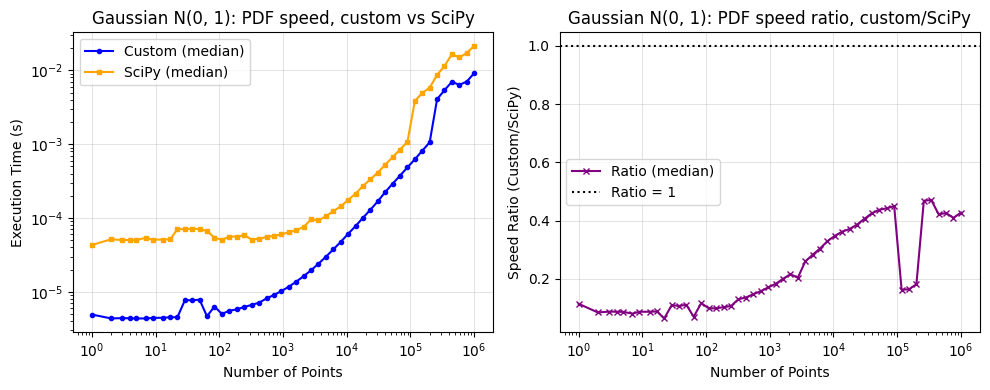

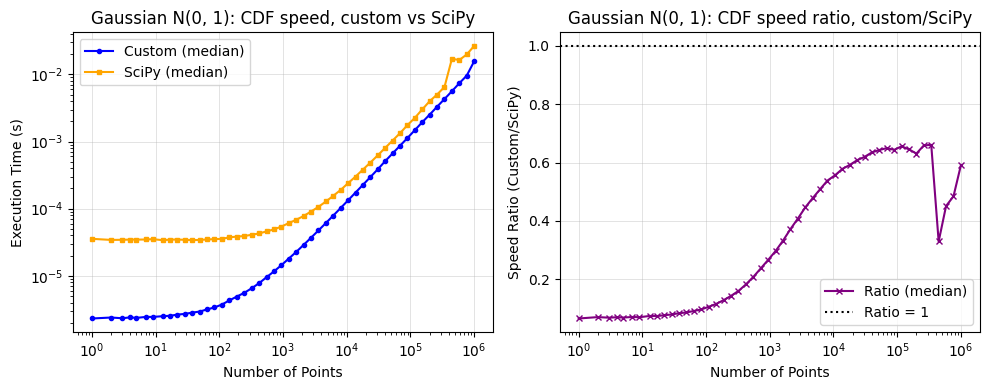

In [4]:
custom_dist = p_dist.GaussianDistribution.from_scipy_params()
scipy_dist = ss.norm()

m_norm1, s_norm1 = cdf_pdf_plots(custom_dist, scipy_dist, n_points_list, "Gaussian N(0, 1)")

## norm(loc=3, scale=0.1)

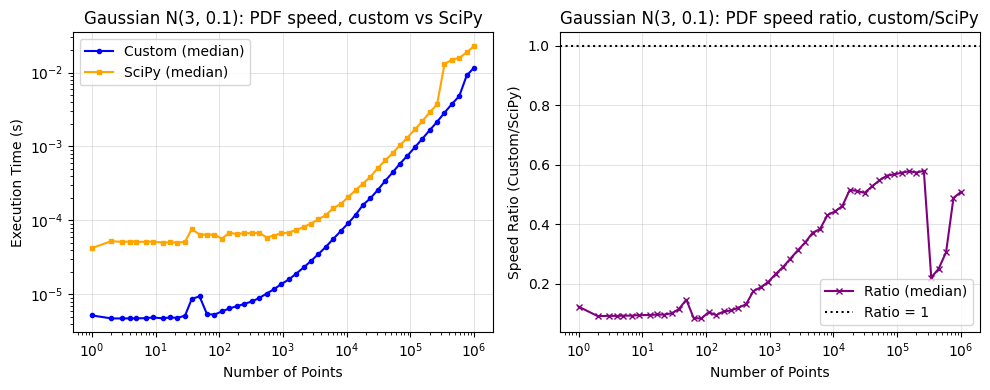

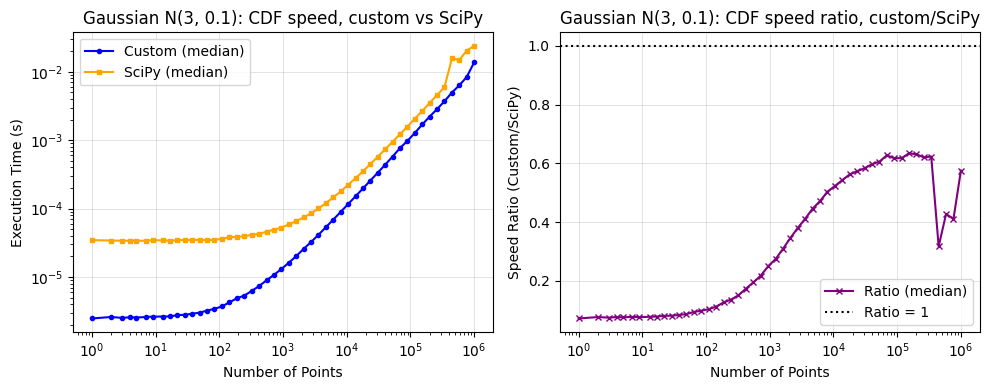

In [5]:
custom_dist = p_dist.GaussianDistribution.from_scipy_params(loc=3, scale=0.1)
scipy_dist = ss.norm(loc=3, scale=0.1)

m_norm2, s_norm2 = cdf_pdf_plots(custom_dist, scipy_dist, n_points_list, "Gaussian N(3, 0.1)")

## laplace(loc=0, scale=1)

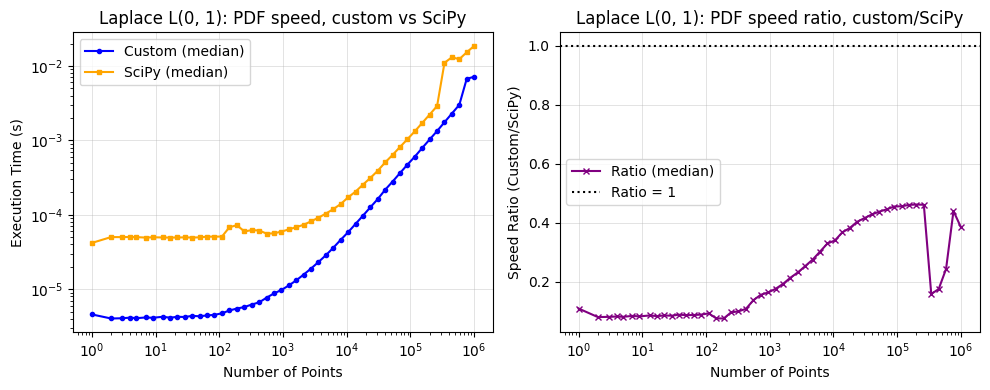

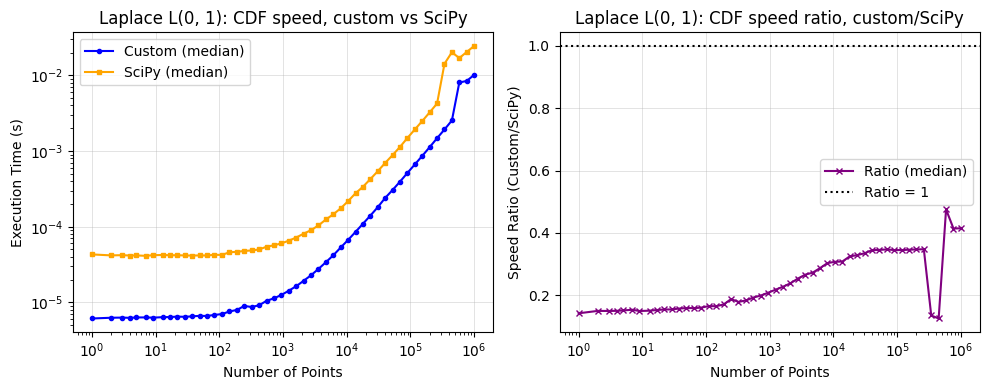

In [6]:
custom_dist = p_dist.LaplaceDistribution.from_scipy_params()
scipy_dist = ss.laplace()

m_laplace1, s_laplace1 = cdf_pdf_plots(custom_dist, scipy_dist, n_points_list, "Laplace L(0, 1)")

## laplace(loc=-3, scale=3)

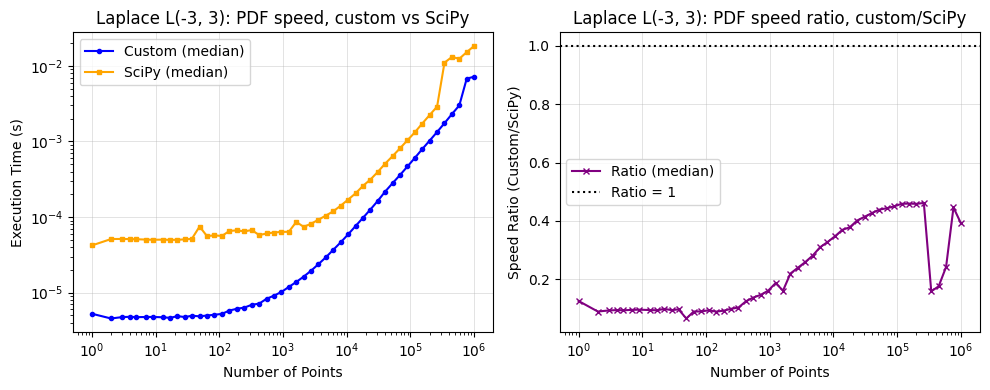

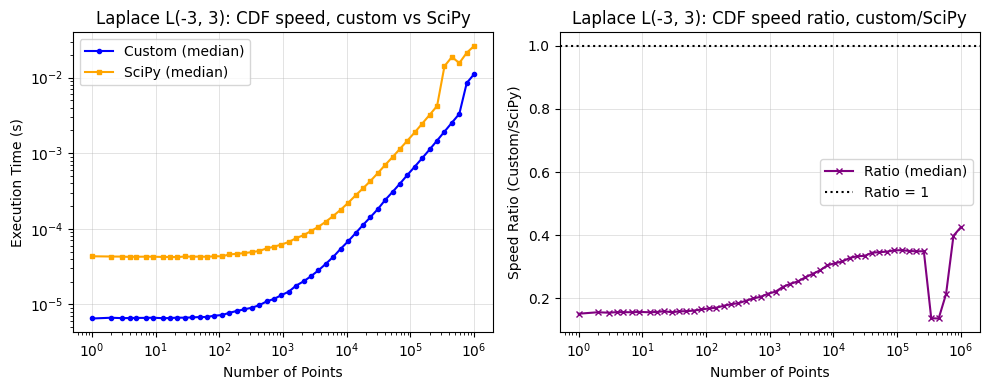

In [7]:
custom_dist = p_dist.LaplaceDistribution.from_scipy_params(loc=-3, scale=3)
scipy_dist = ss.laplace(loc=-3, scale=3)

m_laplace2, s_laplace2 = cdf_pdf_plots(custom_dist, scipy_dist, n_points_list, "Laplace L(-3, 3)")

## skewnorm(a=1, loc=0, scale=1)

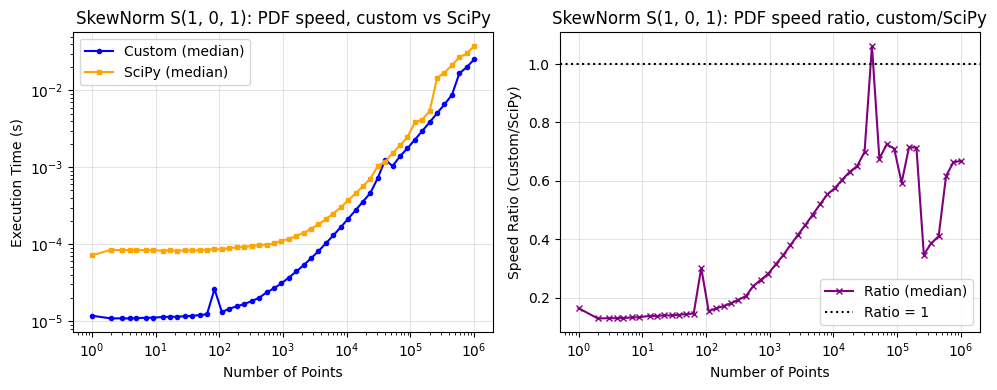

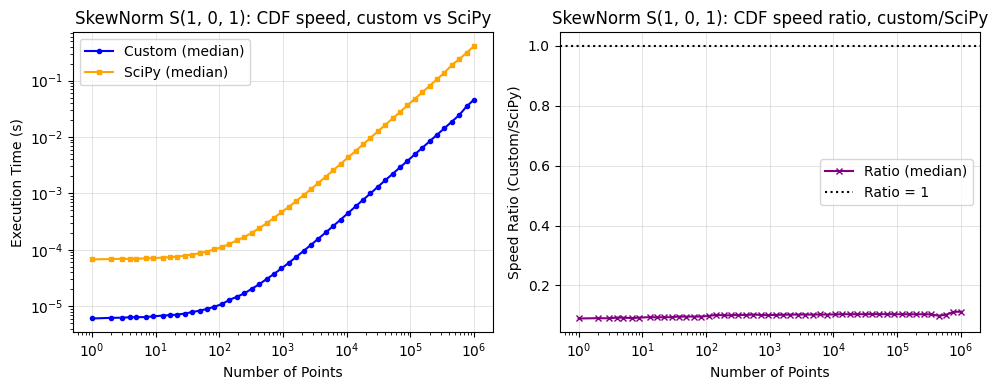

In [8]:
custom_dist = p_dist.SkewNormalDistribution.from_scipy_params(a=1)
scipy_dist = ss.skewnorm(a=1)

m_skewnorm1, s_skewnorm1 = cdf_pdf_plots(custom_dist, scipy_dist, n_points_list, "SkewNorm S(1, 0, 1)")

## skewnorm(a=3, loc=-3, scale=0.5)

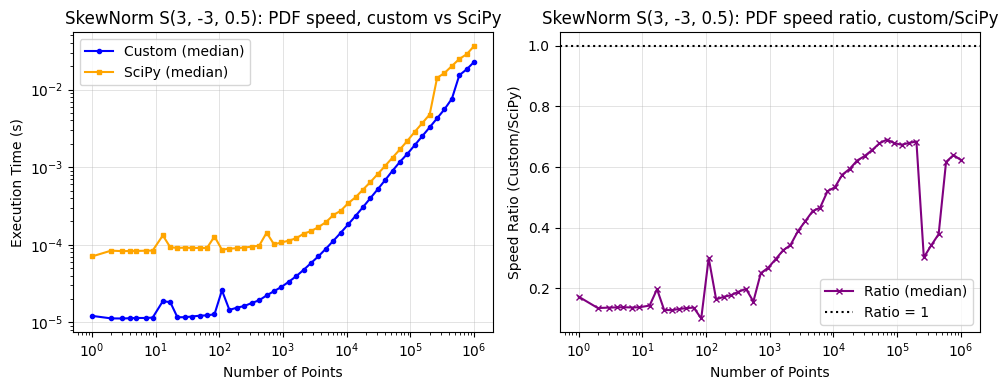

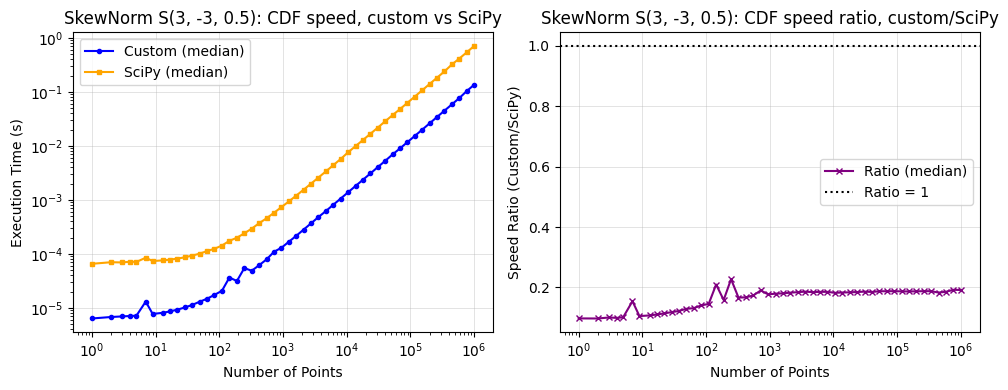

In [9]:
custom_dist = p_dist.SkewNormalDistribution.from_scipy_params(a=3, loc=-3, scale=0.5)
scipy_dist = ss.skewnorm(a=3, loc=-3, scale=0.5)

m_skewnorm2, s_skewnorm2 = cdf_pdf_plots(custom_dist, scipy_dist, n_points_list, "SkewNorm S(3, -3, 0.5)")

## lognorm(s=1, loc=0, scale=1)

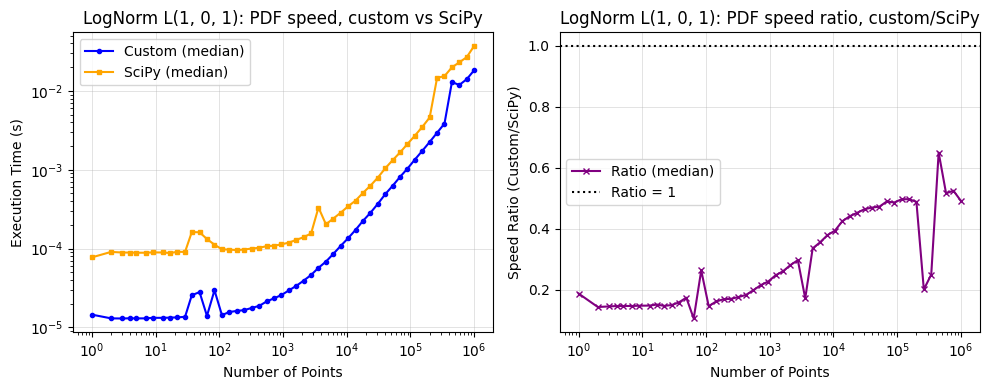

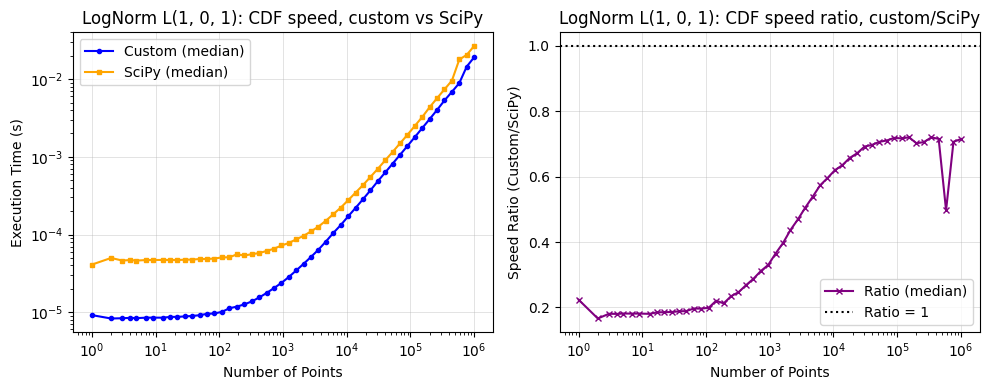

In [10]:
custom_dist = p_dist.LogNormalDistribution.from_scipy_params(s=1, loc=0, scale=1)
scipy_dist = ss.lognorm(s=1, loc=0, scale=1)

m_lognorm1, s_lognorm1 = cdf_pdf_plots(custom_dist, scipy_dist, n_points_list, "LogNorm L(1, 0, 1)")

## lognorm(s=3, loc=-5, scale=0.5)

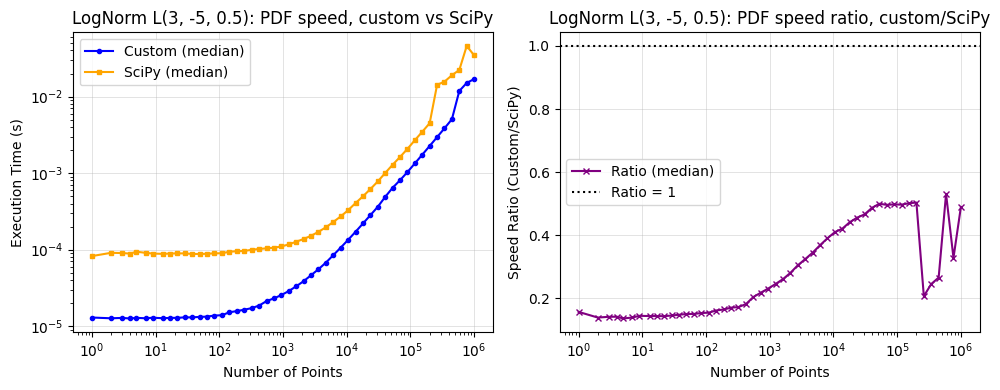

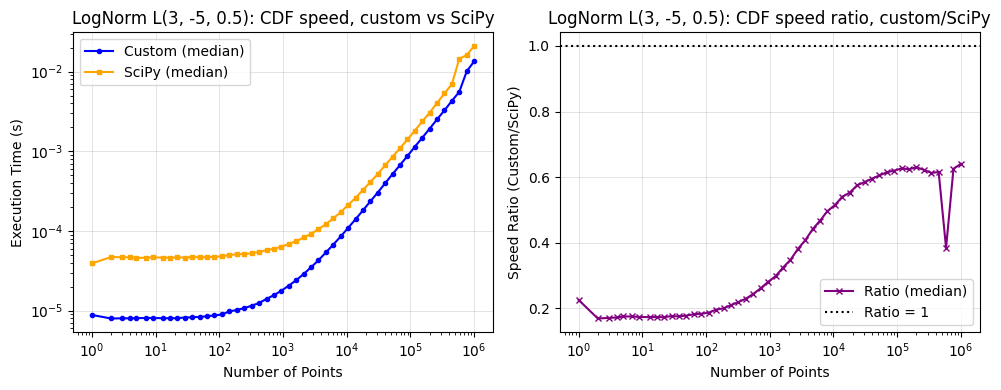

In [11]:
custom_dist = p_dist.LogNormalDistribution.from_scipy_params(s=3, loc=-5, scale=0.5)
scipy_dist = ss.lognorm(s=3, loc=-5, scale=0.5)

m_lognorm2, s_lognorm2 = cdf_pdf_plots(custom_dist, scipy_dist, n_points_list, "LogNorm L(3, -5, 0.5)")

## beta(a=1, b=1)

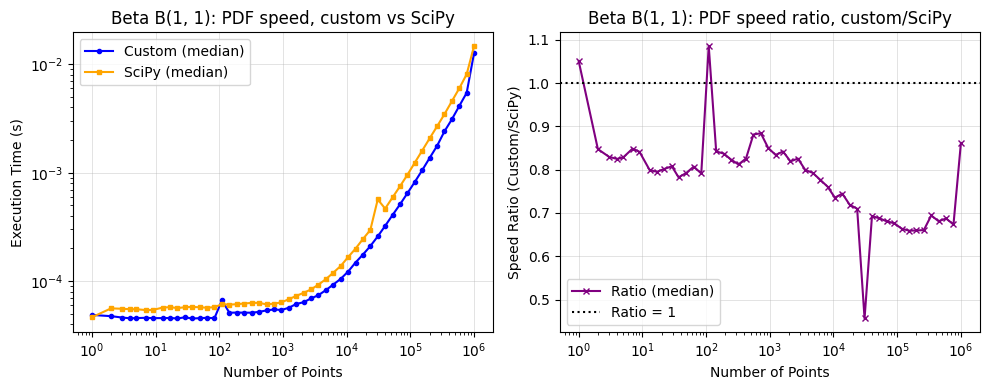

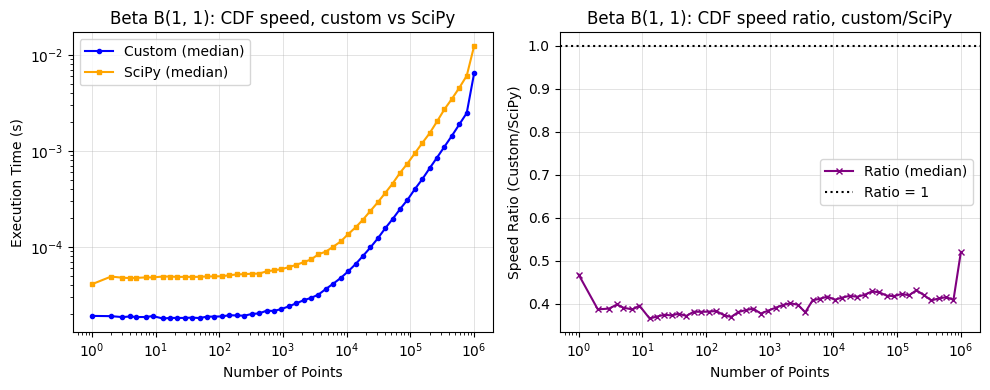

In [12]:
custom_dist = p_dist.BetaDistribution.from_scipy_params(a=1, b=1)
scipy_dist = ss.beta(a=1, b=1)

m_beta1, s_beta1 = cdf_pdf_plots(custom_dist, scipy_dist, n_points_list, "Beta B(1, 1)")

## beta(a=5, b=80, loc=-3, scale=5)

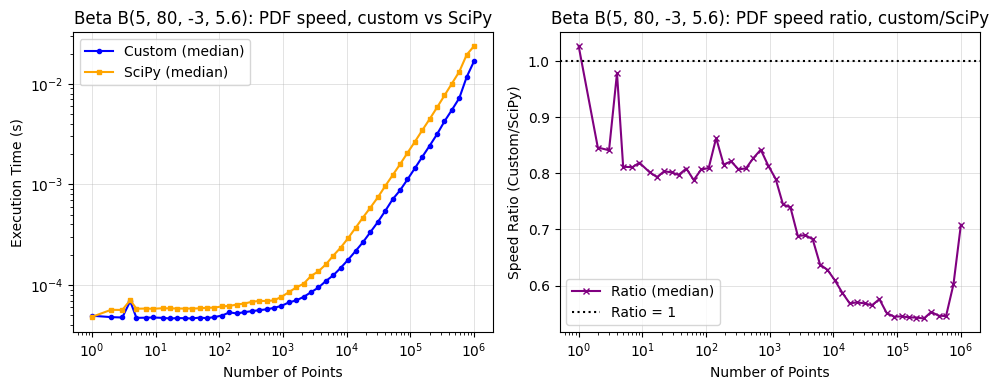

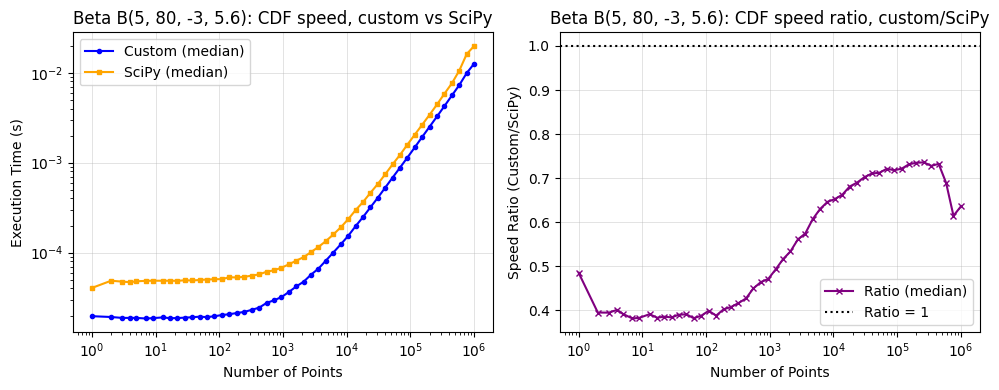

In [13]:
custom_dist = p_dist.BetaDistribution.from_scipy_params(a=5, b=80, loc=-3, scale=5.6)
scipy_dist = ss.beta(a=5, b=80, loc=-3, scale=5.6)

m_beta2, s_beta2 = cdf_pdf_plots(custom_dist, scipy_dist, n_points_list, "Beta B(5, 80, -3, 5.6)")

## arcsine()

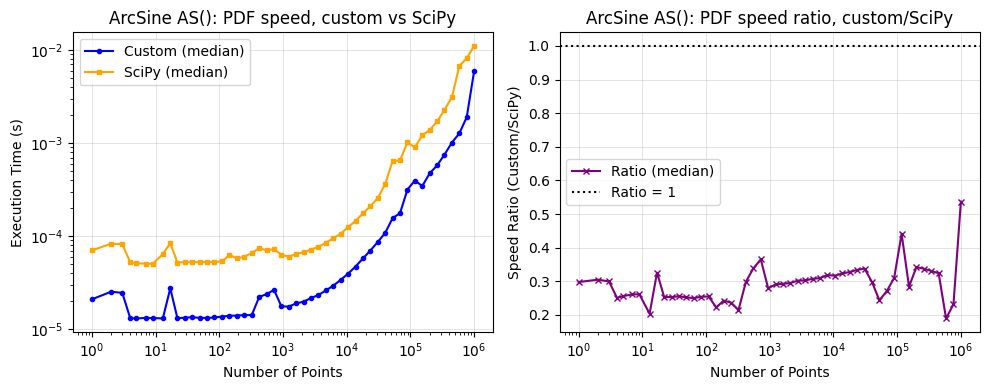

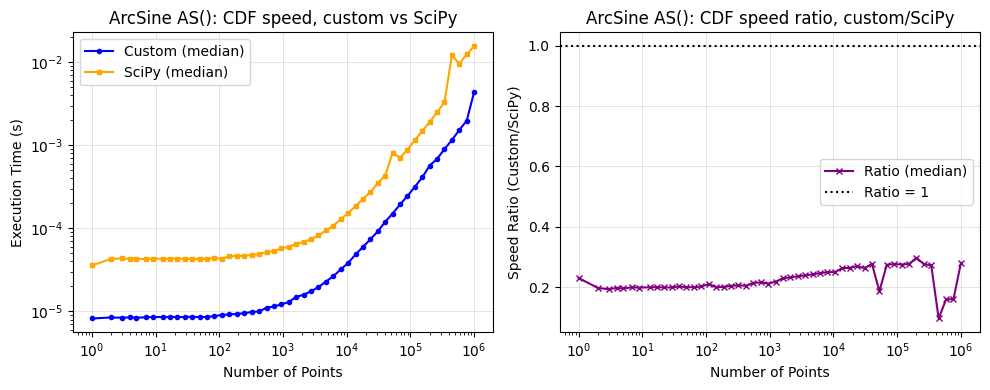

In [14]:
custom_dist = p_dist.ArcSineDistribution.from_scipy_params()
scipy_dist = ss.arcsine()

m_asin1, s_asin1 = cdf_pdf_plots(custom_dist, scipy_dist, n_points_list, "ArcSine AS()")

## arcsine(loc=3, scale=2.2)

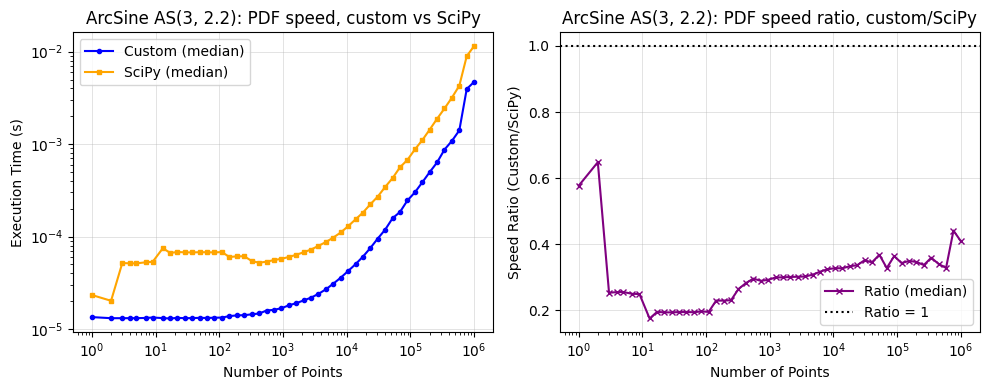

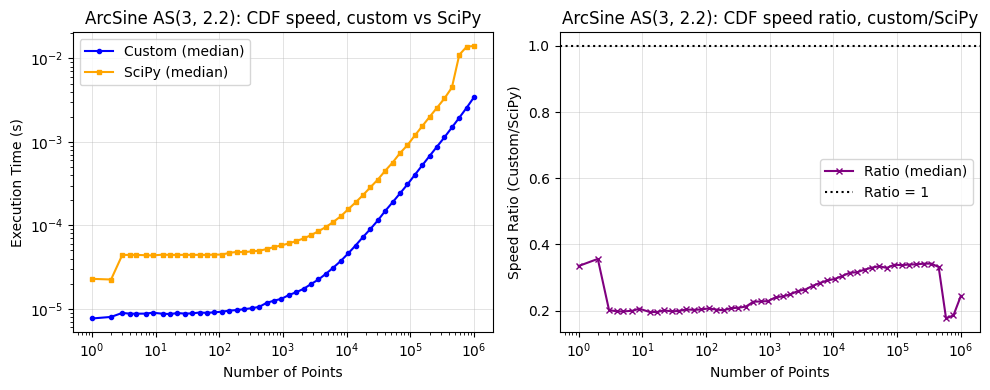

In [15]:
custom_dist = p_dist.ArcSineDistribution.from_scipy_params(loc=3, scale=2.2)
scipy_dist = ss.arcsine(loc=3, scale=2.2)

m_asin2, s_asin2 = cdf_pdf_plots(custom_dist, scipy_dist, n_points_list, "ArcSine AS(3, 2.2)")

## gamma(a=1, loc=0, scale=1)

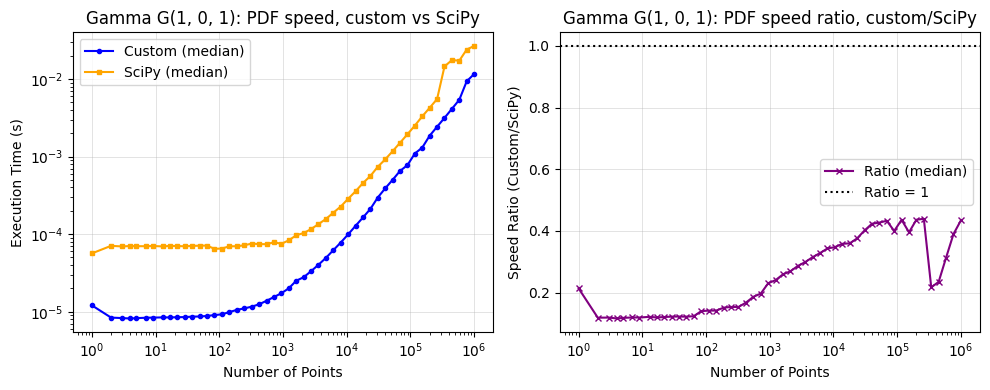

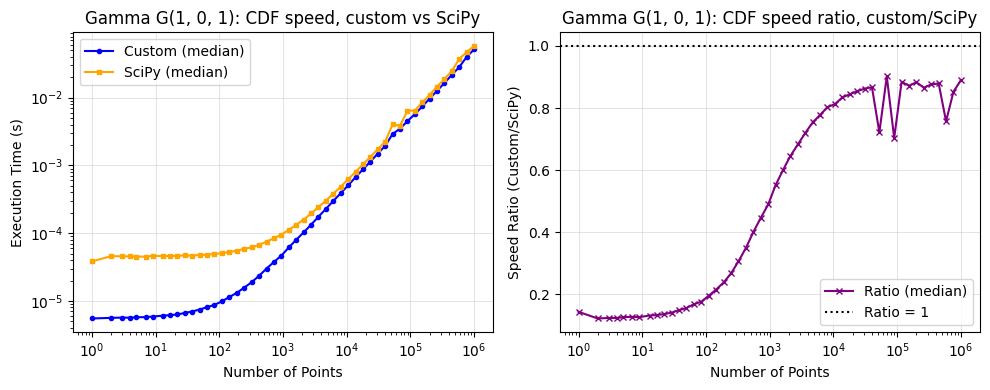

In [16]:
custom_dist = p_dist.GammaDistribution.from_scipy_params(a=1, loc=0, scale=1)
scipy_dist = ss.gamma(a=1, loc=0, scale=1)

m_gamma1, s_gamma1 = cdf_pdf_plots(custom_dist, scipy_dist, n_points_list, "Gamma G(1, 0, 1)")

## gamma(a=1.27, loc=-3, scale=1.5)

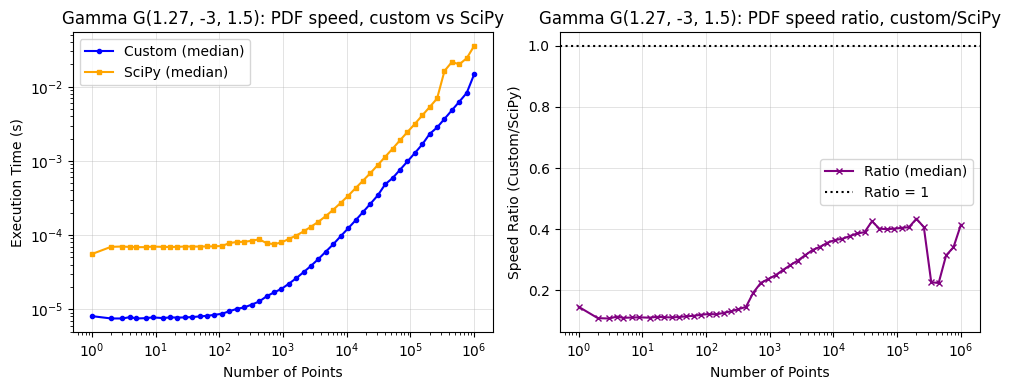

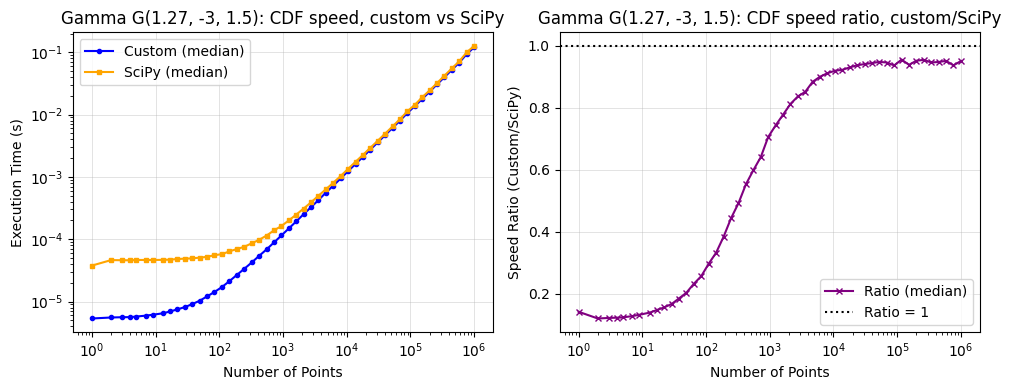

In [17]:
custom_dist = p_dist.GammaDistribution.from_scipy_params(a=1.27, loc=-3, scale=1.5)
scipy_dist = ss.gamma(a=1.27, loc=-3, scale=1.5)

m_gamma2, s_gamma2 = cdf_pdf_plots(custom_dist, scipy_dist, n_points_list, "Gamma G(1.27, -3, 1.5)")

## $\chi^2$(dof=1)

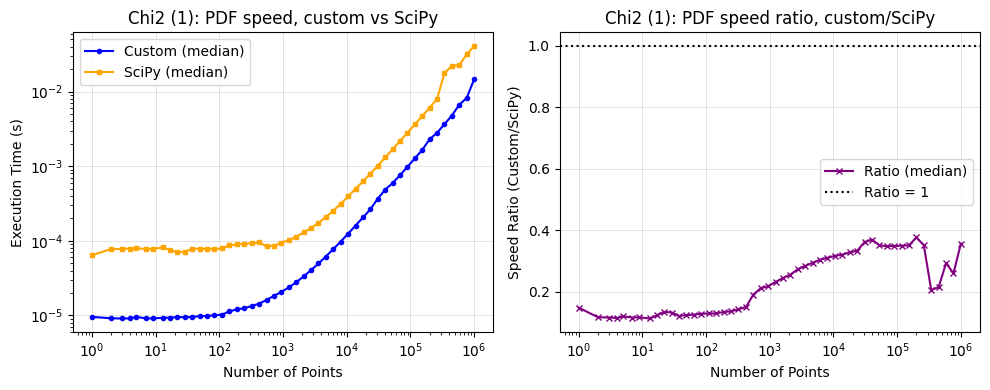

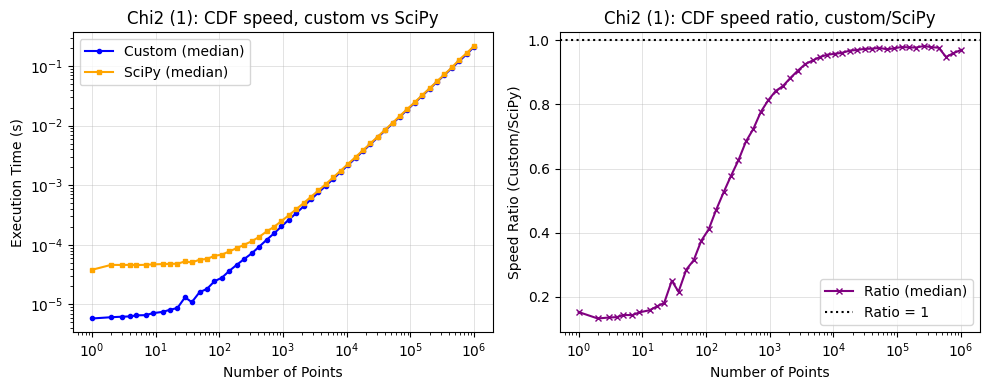

In [18]:
custom_dist = p_dist.ChiSquareDistribution.from_scipy_params(df=1)
scipy_dist = ss.chi2(df=1)

m_chi21, s_chi21 = cdf_pdf_plots(custom_dist, scipy_dist, n_points_list, "Chi2 (1)")

## $\chi^2$(dof=2, loc=-2.3, scale=0.3)

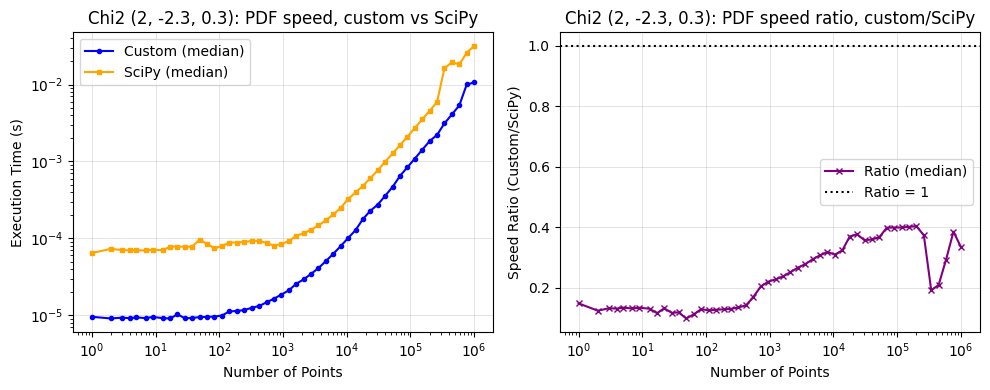

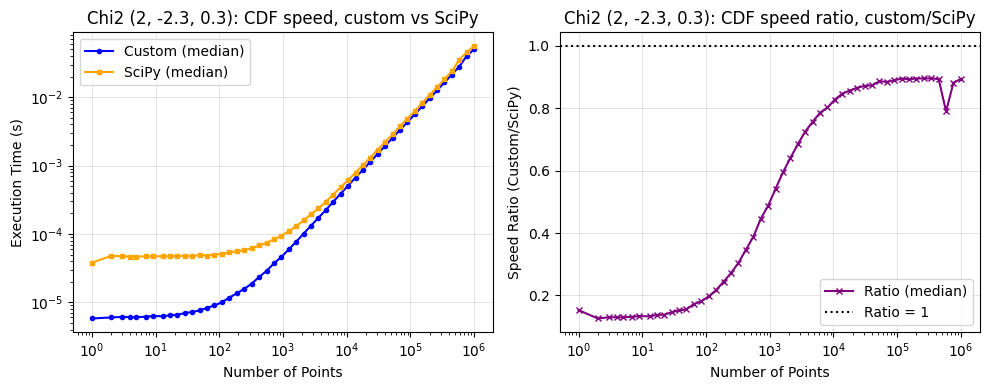

In [19]:
custom_dist = p_dist.ChiSquareDistribution.from_scipy_params(df=2, loc=-2.3, scale=0.3)
scipy_dist = ss.chi2(df=2, loc=-2.3, scale=0.3)

m_chi22, s_chi22 = cdf_pdf_plots(custom_dist, scipy_dist, n_points_list, "Chi2 (2, -2.3, 0.3)")

## $\chi^2$(dof=2.5, loc=-2.3, scale=0.3)

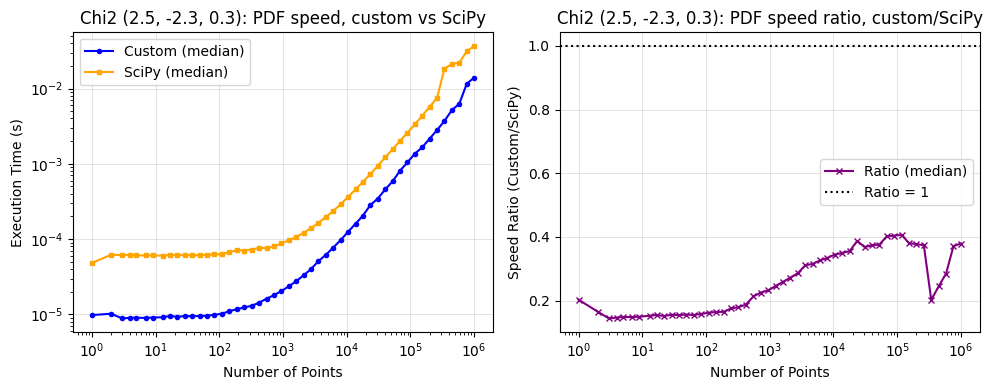

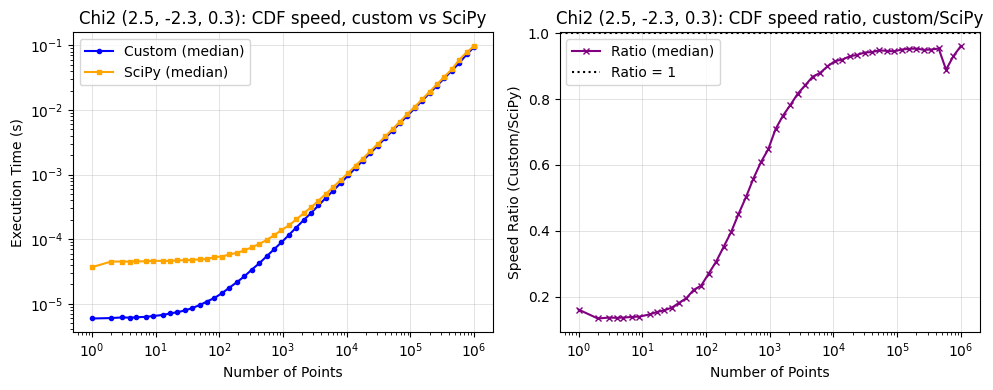

In [20]:
custom_dist = p_dist.ChiSquareDistribution.from_scipy_params(df=2.5, loc=-2.3, scale=0.3)
scipy_dist = ss.chi2(df=2.5, loc=-2.3, scale=0.3)

m_chi23, s_chi23 = cdf_pdf_plots(custom_dist, scipy_dist, n_points_list, "Chi2 (2.5, -2.3, 0.3)")

## foldnorm(mean=2)

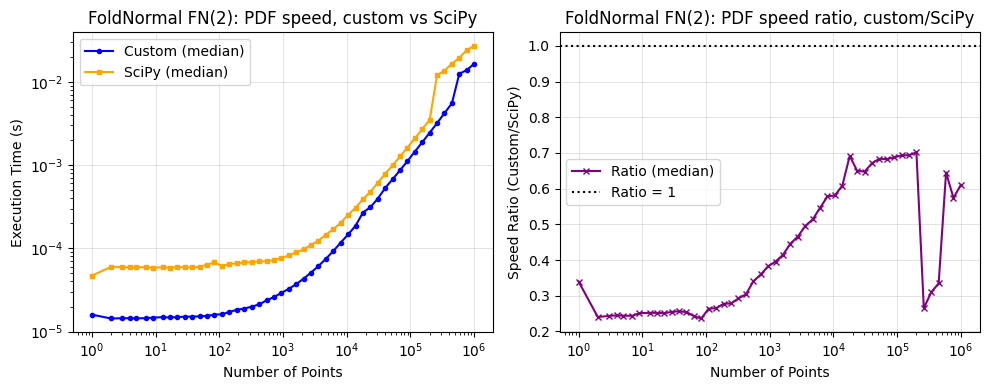

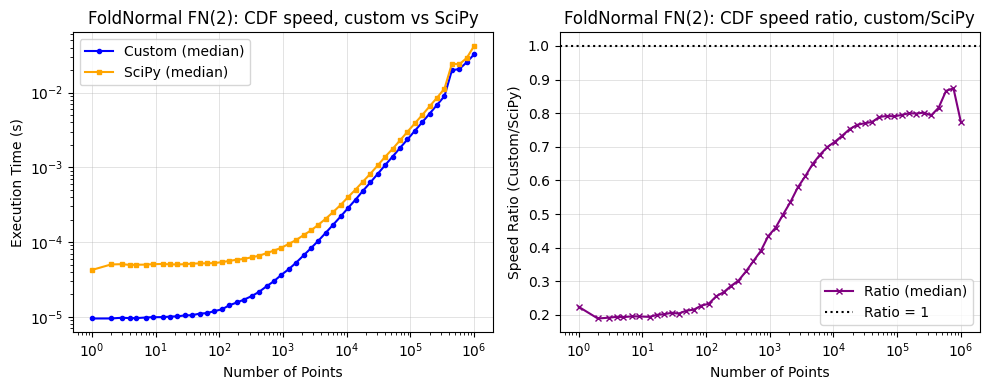

In [21]:
custom_dist = p_dist.FoldedNormalDistribution.from_scipy_params(c=2)
scipy_dist = ss.foldnorm(c=2)

m_fold1, s_fold1 = cdf_pdf_plots(custom_dist, scipy_dist, n_points_list, "FoldNormal FN(2)")

## foldnorm(mean=2, loc=1.4, scale=4)

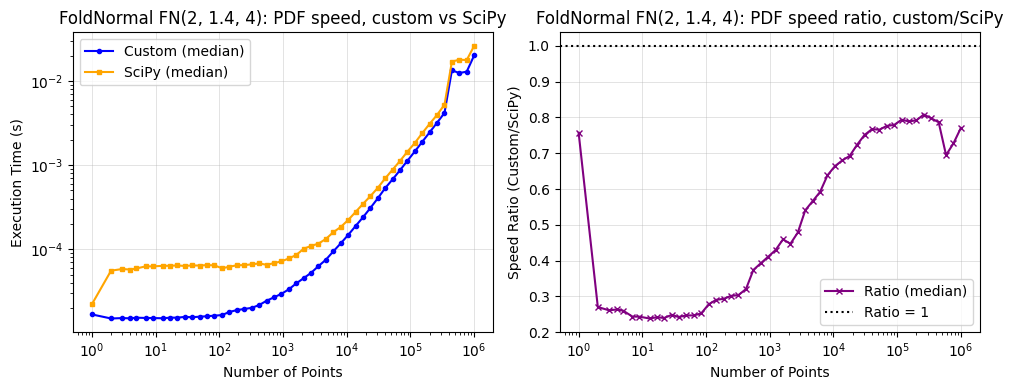

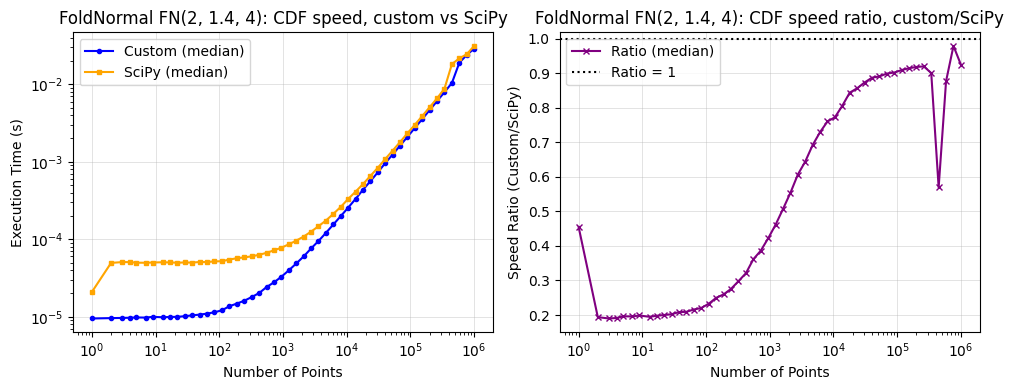

In [22]:
custom_dist = p_dist.FoldedNormalDistribution.from_scipy_params(c=2, loc=1.4, scale=4)
scipy_dist = ss.foldnorm(c=2, loc=1.4, scale=4)

m_fold2, s_fold2 = cdf_pdf_plots(custom_dist, scipy_dist, n_points_list, "FoldNormal FN(2, 1.4, 4)")

## halfNormal(scale=2)

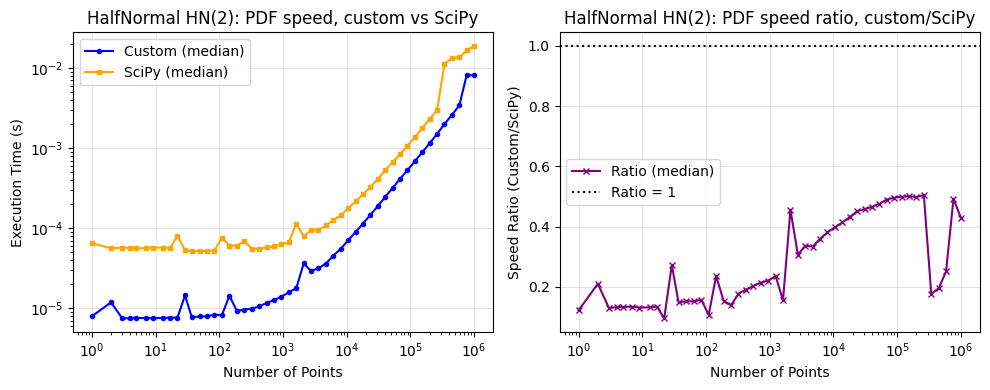

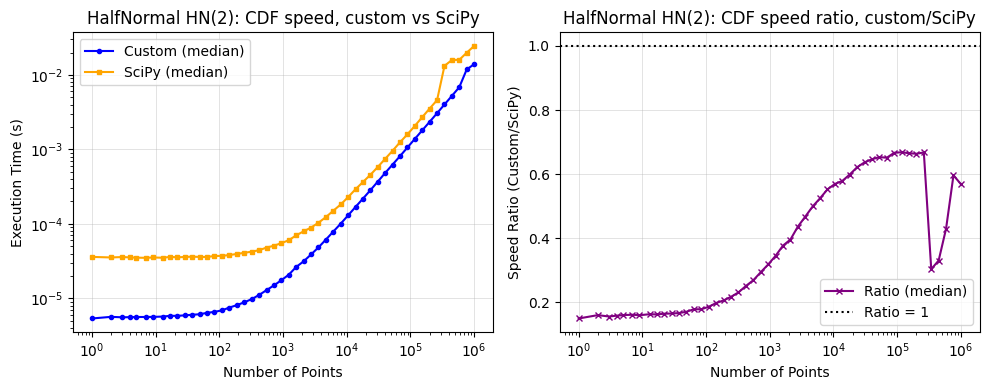

In [23]:
custom_dist = p_dist.HalfNormalDistribution.from_scipy_params(scale=2)
scipy_dist = ss.halfnorm(scale=2)

m_hnorm1, s_hnorm1 = cdf_pdf_plots(custom_dist, scipy_dist, n_points_list, "HalfNormal HN(2)")

## halfnorm(loc=-3, scale=1.3)

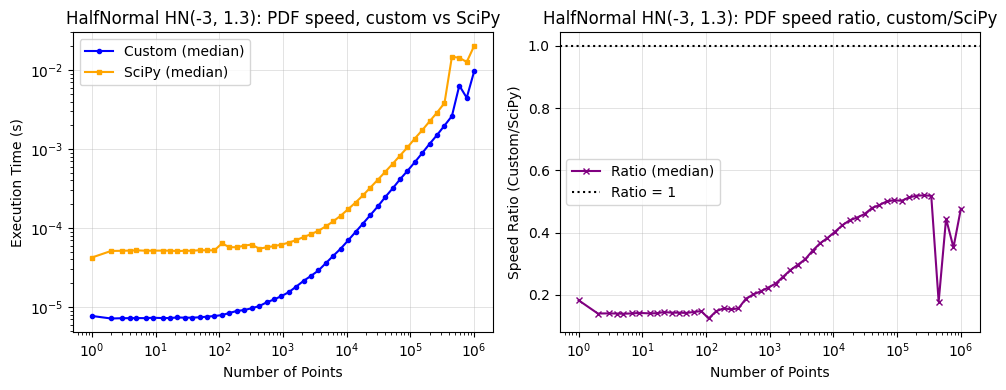

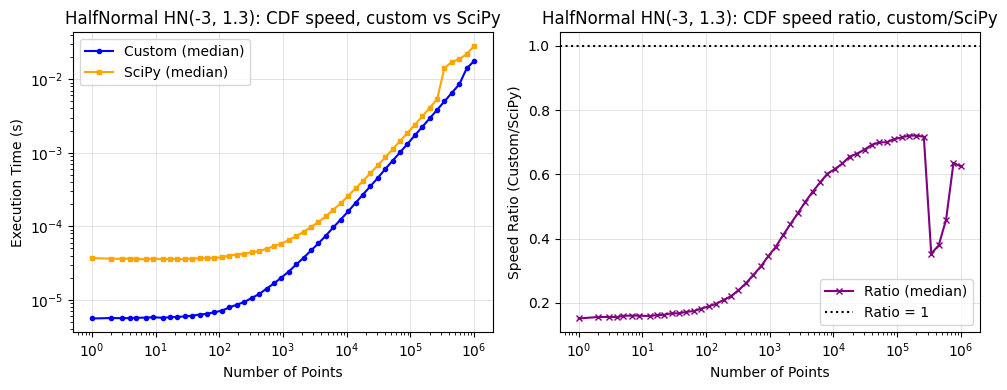

In [24]:
custom_dist = p_dist.HalfNormalDistribution.from_scipy_params(loc=-3, scale=1.3)
scipy_dist = ss.halfnorm(loc=-3, scale=1.3)

m_hnorm2, s_hnorm2 = cdf_pdf_plots(custom_dist, scipy_dist, n_points_list, "HalfNormal HN(-3, 1.3)")

## expon(scale=1.4)

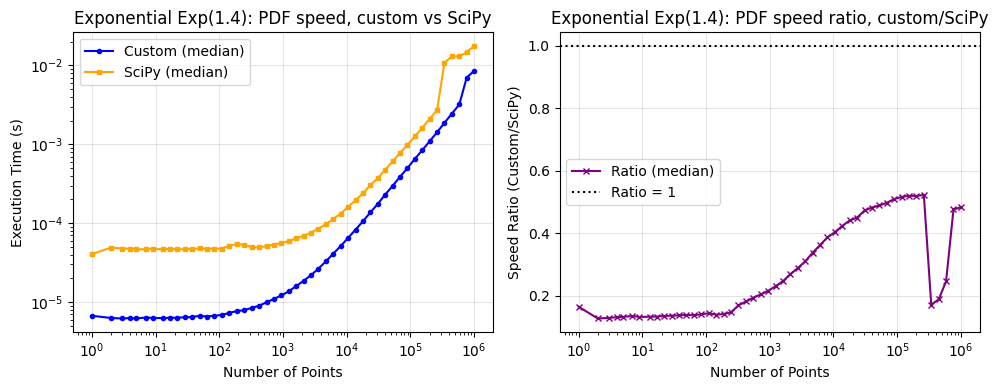

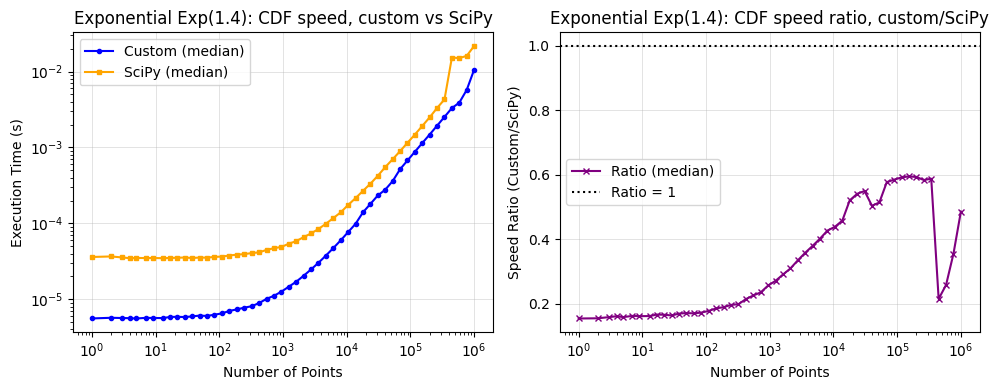

In [25]:
custom_dist = p_dist.ExponentialDistribution.from_scipy_params(scale=1 / 1.4)
scipy_dist = ss.expon(scale=1 / 1.4)

m_exp1, s_exp1 = cdf_pdf_plots(custom_dist, scipy_dist, n_points_list, "Exponential Exp(1.4)")

## expon(loc=-3, scale=1.4)

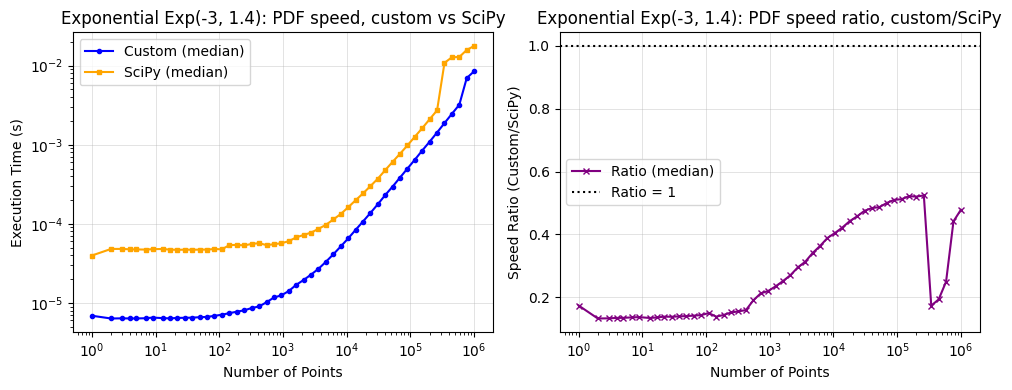

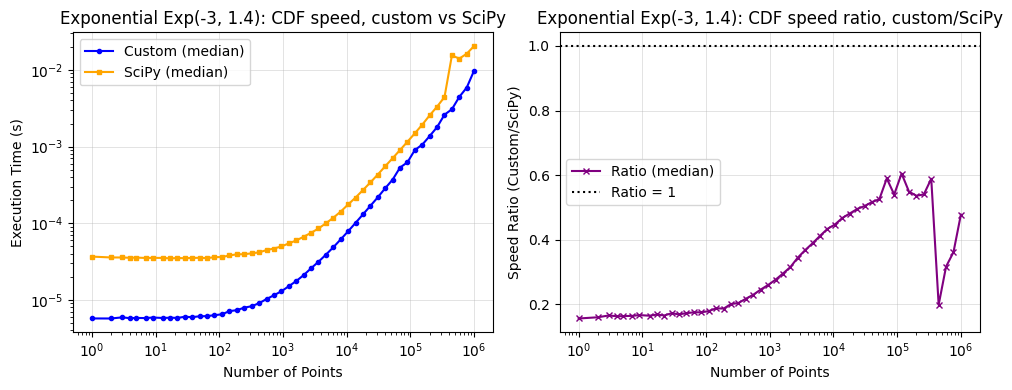

In [26]:
custom_dist = p_dist.ExponentialDistribution.from_scipy_params(loc=-3, scale=1 / 1.4)
scipy_dist = ss.expon(loc=-3, scale=1 / 1.4)

m_exp2, s_exp2 = cdf_pdf_plots(custom_dist, scipy_dist, n_points_list, "Exponential Exp(-3, 1.4)")

## unif(0, 1)

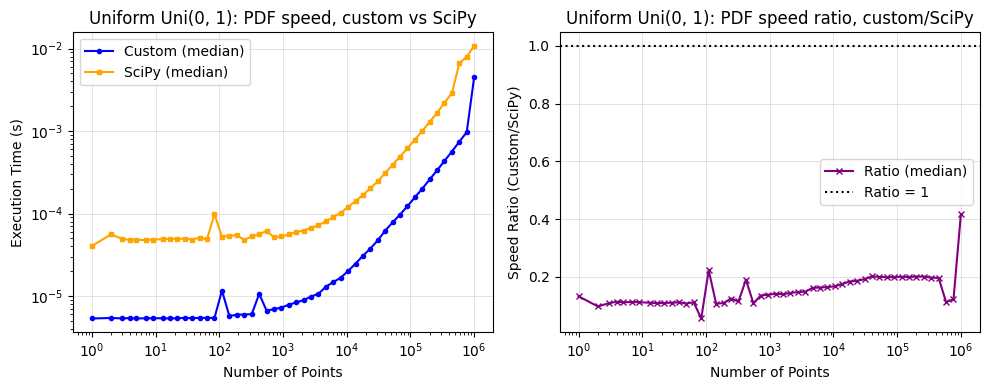

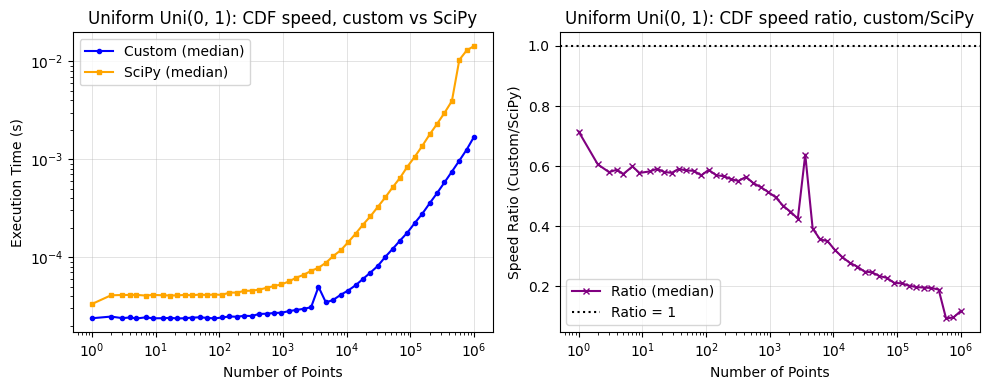

In [27]:
custom_dist = p_dist.UniformDistribution.from_scipy_params()
scipy_dist = ss.uniform()

m_uni1, s_uni1 = cdf_pdf_plots(custom_dist, scipy_dist, n_points_list, "Uniform Uni(0, 1)")

## unif(-3, 2)

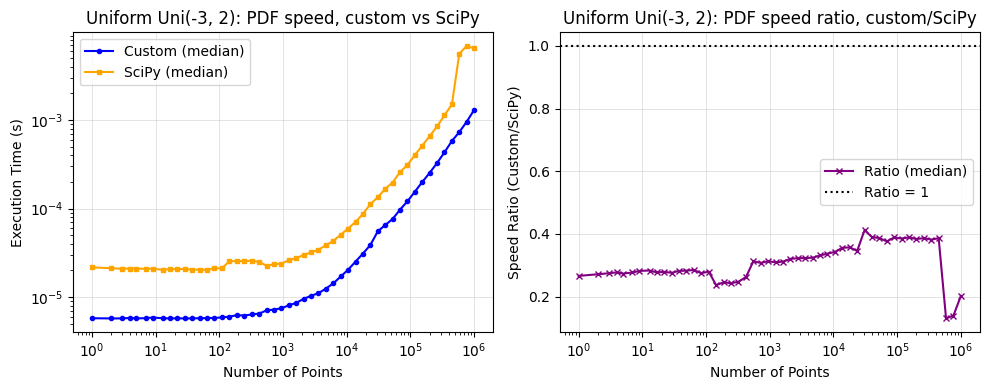

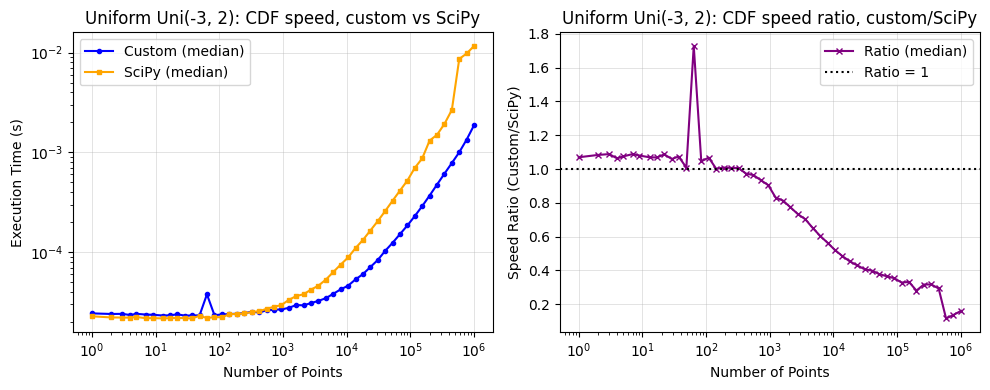

In [28]:
custom_dist = p_dist.UniformDistribution.from_scipy_params(loc=-3, scale=2)
scipy_dist = ss.uniform(loc=-3, scale=2)

m_uni2, s_uni2 = cdf_pdf_plots(custom_dist, scipy_dist, n_points_list, "Uniform Uni(-3, 2)")

## Preparation for summary

In [29]:
pdf_df = pd.DataFrame(
    [
        m_norm1[0],
        m_laplace1[0],
        m_skewnorm1[0],
        m_lognorm1[0],
        m_beta1[0],
        m_asin1[0],
        m_gamma1[0],
        m_chi21[0],
        m_fold1[0],
        m_hnorm1[0],
        m_exp1[0],
        m_uni1[0],
    ]
).T
pdf_df.columns = [
    "norm",
    "laplace",
    "skewnorm",
    "lognorm",
    "beta",
    "arcsine",
    "gamma",
    "chi2",
    "foldnorm",
    "halfnorm",
    "exp",
    "unif",
]

cdf_df = pd.DataFrame(
    [
        m_norm1[1],
        m_laplace1[1],
        m_skewnorm1[1],
        m_lognorm1[1],
        m_beta1[1],
        m_asin1[1],
        m_gamma1[1],
        m_chi21[1],
        m_fold1[1],
        m_hnorm1[1],
        m_exp1[1],
        m_uni1[1],
    ]
).T

cdf_df.columns = [
    "norm",
    "laplace",
    "skewnorm",
    "lognorm",
    "beta",
    "arcsine",
    "gamma",
    "chi2",
    "foldnorm",
    "halfnorm",
    "exp",
    "unif",
]

pdf_df.to_csv(RESULTS / "PDF_multifit_df.csv", index=False)
cdf_df.to_csv(RESULTS / "CDF_multifit_df.csv", index=False)

In [30]:
pdf_df = pd.DataFrame(
    [
        s_norm1[0],
        s_laplace1[0],
        s_skewnorm1[0],
        s_lognorm1[0],
        s_beta1[0],
        s_asin1[0],
        s_gamma1[0],
        s_chi21[0],
        s_fold1[0],
        s_hnorm1[0],
        s_exp1[0],
        s_uni1[0],
    ]
).T
pdf_df.columns = [
    "norm",
    "laplace",
    "skewnorm",
    "lognorm",
    "beta",
    "arcsine",
    "gamma",
    "chi2",
    "foldnorm",
    "halfnorm",
    "exp",
    "unif",
]

cdf_df = pd.DataFrame(
    [
        s_norm1[1],
        s_laplace1[1],
        s_skewnorm1[1],
        s_lognorm1[1],
        s_beta1[1],
        s_asin1[1],
        s_gamma1[1],
        s_chi21[1],
        s_fold1[1],
        s_hnorm1[1],
        s_exp1[1],
        s_uni1[1],
    ]
).T

cdf_df.columns = [
    "norm",
    "laplace",
    "skewnorm",
    "lognorm",
    "beta",
    "arcsine",
    "gamma",
    "chi2",
    "foldnorm",
    "halfnorm",
    "exp",
    "unif",
]

pdf_df.to_csv(RESULTS / "PDF_scipy_df.csv", index=False)
cdf_df.to_csv(RESULTS / "CDF_scipy_df.csv", index=False)

In [31]:
pdf_df = pd.DataFrame(
    [
        m_norm2[0],
        m_laplace2[0],
        m_skewnorm2[0],
        m_lognorm2[0],
        m_beta2[0],
        m_asin2[0],
        m_gamma2[0],
        m_chi22[0],
        m_fold2[0],
        m_hnorm2[0],
        m_exp2[0],
        m_uni2[0],
    ]
).T

pdf_df.columns = [
    "norm",
    "laplace",
    "skewnorm",
    "lognorm",
    "beta",
    "arcsine",
    "gamma",
    "chi2",
    "foldnorm",
    "halfnorm",
    "exp",
    "unif",
]

cdf_df = pd.DataFrame(
    [
        m_norm2[1],
        m_laplace2[1],
        m_skewnorm2[1],
        m_lognorm2[1],
        m_beta2[1],
        m_asin2[1],
        m_gamma2[1],
        m_chi22[1],
        m_fold2[1],
        m_hnorm2[1],
        m_exp2[1],
        m_uni2[1],
    ]
).T

cdf_df.columns = [
    "norm",
    "laplace",
    "skewnorm",
    "lognorm",
    "beta",
    "arcsine",
    "gamma",
    "chi2",
    "foldnorm",
    "halfnorm",
    "exp",
    "unif",
]

pdf_df.to_csv(RESULTS / "PDF_multifit_variable_df.csv", index=False)
cdf_df.to_csv(RESULTS / "CDF_multifit_variable_df.csv", index=False)

In [32]:
pdf_df = pd.DataFrame(
    [
        s_norm2[0],
        s_laplace2[0],
        s_skewnorm2[0],
        s_lognorm2[0],
        s_beta2[0],
        s_asin2[0],
        s_gamma2[0],
        s_chi22[0],
        s_fold2[0],
        s_hnorm2[0],
        s_exp2[0],
        s_uni2[0],
    ]
).T
pdf_df.columns = [
    "norm",
    "laplace",
    "skewnorm",
    "lognorm",
    "beta",
    "arcsine",
    "gamma",
    "chi2",
    "foldnorm",
    "halfnorm",
    "exp",
    "unif",
]

cdf_df = pd.DataFrame(
    [
        s_norm2[1],
        s_laplace2[1],
        s_skewnorm2[1],
        s_lognorm2[1],
        s_beta2[1],
        s_asin2[1],
        s_gamma2[1],
        s_chi22[1],
        s_fold2[1],
        s_hnorm2[1],
        s_exp2[1],
        s_uni2[1],
    ]
).T

cdf_df.columns = [
    "norm",
    "laplace",
    "skewnorm",
    "lognorm",
    "beta",
    "arcsine",
    "gamma",
    "chi2",
    "foldnorm",
    "halfnorm",
    "exp",
    "unif",
]

pdf_df.to_csv(RESULTS / "PDF_scipy_variable_df.csv", index=False)
cdf_df.to_csv(RESULTS / "CDF_scipy_variable_df.csv", index=False)